In [1]:
pip install requests beautifulsoup4 lxml

Note: you may need to restart the kernel to use updated packages.


### Building a function to parse recipes from websites

In [128]:
import requests 
from bs4 import BeautifulSoup
import json

# Extract ingredient list from a recipe page using schema.org JSON-LD
def extract_ingredients(url):
    headers = {
    "User-Agent": "Chrome/91.0.4472.120"
    }
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "lxml")
    scripts = soup.find_all("script", type="application/ld+json")
    for script in scripts:
        if not script.string:
            continue
        if "recipeIngredient" not in script.string:
            continue
        try: 
            data = json.loads(script.string.strip())
        except json.JSONDecodeError:
            continue

        # handle simple Recipe JSON directly
        if isinstance(data, dict) and data.get("@type") == "Recipe": 
            ingredients = data.get("recipeIngredient", [])
            return {"Recipe_url": url, "Ingredients": ingredients}

        if isinstance(data, dict):
            candidates = data.get("@graph", [data])

        elif isinstance(data, list):
            candidates = data 
        
        else: 
            continue

        for item in candidates:
            if not isinstance(item, dict):
                continue
            
            ingredients = item.get("recipeIngredient", [])
            
            if ingredients:
                return {"Recipe_url": url, "Ingredients": ingredients}
         
    return None 


In [129]:
test = extract_ingredients("https://ashbaber.com/easy-fudgy-blondies/")
print(test)

{'Recipe_url': 'https://ashbaber.com/easy-fudgy-blondies/', 'Ingredients': ['160g unsalted butter', '200g brown sugar', '100g granulated sugar', '2 teaspoons vanilla extract', '2 eggs', '240g plain flour', '1/2 teaspoon salt', '1/4 teaspoon baking powder', '150g chocolate, chopped (I used a mixture of white and dark chocolate)']}


### Making a dataframe (df) out of the parsed data

In [130]:
import pandas as pd

df_urls = pd.read_csv("blondie_urls.csv")

df_urls.describe()

df_urls = df_urls.drop_duplicates(subset=["URLs"])
df_urls = df_urls.dropna(subset=["URLs"])

In [131]:
urls = df_urls["URLs"].tolist()
print(len(urls))

35


In [132]:
dataset = []
for url in urls:
    recipe = extract_ingredients(url)
    if recipe:
        dataset.append(recipe)
    else:
        print(f"Failed to extract from: {url}")

Failed to extract from: https://www.inspiredtaste.net/23801/no-fail-blondies-recipe/ 
Failed to extract from: https://smittenkitchen.com/2006/11/blondies/
Failed to extract from: https://www.thepancakeprincess.com/best-blondie-bake-off/
Failed to extract from: https://fussfreeflavours.com/best-blondie-recipes/


In [133]:
print(len(dataset))

31


In [134]:
df = pd.DataFrame(dataset)

df.describe()

,Recipe_url,Ingredients
count,31,31
unique,31,31
top,https://sugarspunrun.com/blondies-recipe/,"[1 cup unsalted butter (melted), 1 ¼ cup brown..."
freq,1,1


In [9]:
df["Ingredients"].sample(20)

17    [1 cup (8 oz/225 g) butter,  (melted and coole...
22    [150g unsalted butter, cold from the fridge is...
0     [1 cup unsalted butter (melted), 1 ¼ cup brown...
14    [½ cup butter (softened), 2 cups brown sugar, ...
4     [1 cup (about 100 grams) walnut halves and pie...
9     [1¾ cups all purpose flour, ¼ cup cornstarch, ...
20    [½  cup unsalted butter, melted ((1 stick)), 1...
16    [1 ¼ cup brown sugar, 2 large eggs, 2 teaspoon...
1     [1¾ cups all-purpose flour ((210g)), 1 teaspoo...
7     [Â¾ cup unsalted butter (melted and slightly c...
10    [12 tbsp (1 ½ sticks) unsalted butter, 2 large...
26    [1 1/2  cups    butter, softened , 1 2/3  cups...
5     [2 cups all-purpose flour, 1 teaspoon baking p...
3     [¾ cup unsalted butter (1½ sticks, sliced into...
24    [3/4 c. unsalted butter, Nonstick cooking spra...
25    [1 cup (2 sticks / 227 g) unsalted butter, (me...
21    [2 1/2 cups All purpose flour (300g), 1 tsp Ba...
19    [175g  butter cut into cubes, plus extra f

### Altering the df to show each ingredient instead of the recipe as a whole

In [10]:
df = df.explode("Ingredients").reset_index(drop=True)

In [11]:
print(len(df))

239


### Making a "grams" column in df to show the weight of ingredients in grams

In [12]:
def get_grams(text):
    import re
    match = re.search(r"(\d+\.?\d*)\s*g", text.lower())
    if match:
        return float(match.group(1))
    return None

In [13]:
df["grams"] = df["Ingredients"].apply(get_grams)

In [14]:
df.sample(10)

,Recipe_url,Ingredients,grams
205,https://veenaazmanov.com/classic-blondies-recipe/,1 tsp Baking powder,NaN
187,https://www.cookwithkushi.com/best-blondie-rec...,2 Eggs,NaN
170,https://www.bbcgoodfood.com/recipes/easy-blondies,1 tsp vanilla extract or bean paste,NaN
199,https://veenaazmanov.com/classic-blondies-recipe/,1 cup Unsalted butter (almost melted),NaN
203,https://veenaazmanov.com/classic-blondies-recipe/,2 tsp Vanilla extract,NaN
113,https://www.somethingswanky.com/classic-chocol...,"1 large egg, beaten",NaN
17,https://preppykitchen.com/blondie-recipe/,1 large egg (room temperature),NaN
71,https://www.livewellbakeoften.com/blondie-recipe/,2 cups all-purpose flour,NaN
235,https://www.food.com/recipe/classic-blondies-5...,1 cup semi-sweet chocolate chips,NaN
79,https://handletheheat.com/blondie-recipe/,1/2 teaspoon fine sea salt,NaN


### Normalising fractions in list of ingredients

In [15]:
df[df["Ingredients"].str.contains("⅕|⅖|⅗|⅘",na=False)]

,Recipe_url,Ingredients,grams


In [16]:
df[df["Ingredients"].str.contains("11/2",na=False)]

,Recipe_url,Ingredients,grams


In [17]:
def normalise_fractions(text):
    import re
    
    # Step 1: add space between number and unicode fraction
    text = re.sub(r"(\d)([½¼¾⅓⅔])", r"\1 \2", text)

    replacements = {
        "½": "1/2",
        "¼": "1/4",
        "¾": "3/4",
        "⅓": "1/3",
        "⅔": "2/3"}
    for k, v in replacements.items():
        text = text.replace(k, v)
    return text

In [18]:
df["Ingredients"] = df["Ingredients"].apply(normalise_fractions)

In [19]:
df[df["Ingredients"].str.contains("½|¼|¾|⅓|⅔",na=False)]

,Recipe_url,Ingredients,grams


### Ensuring compact fractions are fixed (eg: 13/4 is computed as 1 and 3/4 instead of 13/4)

In [20]:
def fix_compact_fractions(text):
    import re
    text = re.sub(r"\b(\d)(\d)/(\d)\b", r"\1 \2/\3", text)
    return text

In [21]:
df["Ingredients"] = df["Ingredients"].apply(fix_compact_fractions)

In [22]:
df[df["Ingredients"].str.contains("13/4",na=False)]

,Recipe_url,Ingredients,grams


In [23]:
df[df["Ingredients"].str.contains("11/2",na=False)]

,Recipe_url,Ingredients,grams


### Extracts the first numeric amount from a text string; handles **mixed numbers**(1 1/2), **fractions** (3/4) and **integers/decimals**(2 or 2.5)

In [24]:
def get_amount(text):
    import re
    match = re.search(r"(\d+\s\d+/\d+|\d+/\d+|\d+\.?\d*)", text)
    if match:
        return match.group(1)
    return None

df["amount_raw"] = df["Ingredients"].apply(get_amount)

### Converting the numeric amount into float

In [25]:
def amount_to_float(text):
    if text is None:
        return None
    # case 1: Mixed number (e.g., "1 1/2")
    if " " in text:
        whole, frac = text.split(" ")
        num, den = frac.split("/")
        return float(whole) + float(num) / float(den)
    # case 2: Simple fraction (e.g., "1/2")
    if "/" in text:
        num, den = text.split("/")
        return float(num) / float(den)
    # case 3: Simple number (e.g., "1", "1.5")
    return float(text)

In [26]:
df["amount_float"] = df["amount_raw"].apply(amount_to_float)

In [27]:
df.sample(10)

,Recipe_url,Ingredients,grams,amount_raw,amount_float
0,https://sugarspunrun.com/blondies-recipe/,1 cup unsalted butter (melted),NaN,1,1.00
73,https://www.livewellbakeoften.com/blondie-recipe/,Â1/2 teaspoon salt,NaN,1/2,0.50
28,https://www.recipetineats.com/blondies/,1/4 tsp sea salt flakes,NaN,1/4,0.25
10,https://sugarspunrun.com/blondies-recipe/,"1 cup chopped walnuts ((may omit, see note))",NaN,1,1.00
86,https://cakesbymk.com/recipe/easy-blondies-rec...,1/2 tsp baking powder,NaN,1/2,0.50
68,https://www.livewellbakeoften.com/blondie-recipe/,Â3/4 cup granulated sugar ((150 grams) ),150.0,3/4,0.75
219,https://www.thepioneerwoman.com/food-cooking/r...,1 1/2 c. butterscotch or white chocolate chips...,NaN,1 1/2,1.50
36,https://www.loveandlemons.com/blondie-recipe/,1/2 cup chopped walnuts (plus more for topping),NaN,1/2,0.50
104,https://bromabakery.com/the-best-chewy-blondies/,1 cup packed light brown sugar,NaN,1,1.00
8,https://sugarspunrun.com/blondies-recipe/,1 teaspoon salt,NaN,1,1.00


In [28]:
df[df["Ingredients"].str.contains("gram", na=False)]

,Recipe_url,Ingredients,grams,amount_raw,amount_float
38,https://joythebaker.com/2023/02/my-best-classi...,1 cup (about 100 grams) walnut halves and pieces,100.0,1,1.00
39,https://joythebaker.com/2023/02/my-best-classi...,1 1/2 cups (190 grams) all-purpose flour,190.0,1 1/2,1.50
42,https://joythebaker.com/2023/02/my-best-classi...,"1 1/2 sticks (12 tablespoons, 179 grams) unsal...",179.0,1 1/2,1.50
43,https://joythebaker.com/2023/02/my-best-classi...,1 1/4 cup (250 grams) lightly packed light or ...,250.0,1 1/4,1.25
66,https://www.livewellbakeoften.com/blondie-recipe/,Â3/4 cup unsalted butter (melted and slightly ...,170.0,3/4,0.75
67,https://www.livewellbakeoften.com/blondie-recipe/,1 cup packed light brown sugar ((200 grams) ),200.0,1,1.00
68,https://www.livewellbakeoften.com/blondie-recipe/,Â3/4 cup granulated sugar ((150 grams) ),150.0,3/4,0.75
74,https://www.livewellbakeoften.com/blondie-recipe/,1 cup white chocolate chips (optional (190 gra...,190.0,1,1.00
75,https://handletheheat.com/blondie-recipe/,1 1/2 sticks (170 grams) unsalted butter,170.0,1 1/2,1.50
76,https://handletheheat.com/blondie-recipe/,1 1/2 cups (300 grams) light brown sugar,300.0,1 1/2,1.50


In [29]:
df[df["Recipe_url"].str.contains("ashbaber", na=False)]

,Recipe_url,Ingredients,grams,amount_raw,amount_float


### Extracting unit of measurement of each ingredient

In [30]:
def get_unit(text):
    import re
    match = re.search(r"\b(cups|cup|c\.|tablespoons|tablespoon|teaspoons|teaspoon|tbsp|tsps|tsp|grams|gram|g|sticks|stick|ounces|ounce|oz)", text.lower())
    if match:
        unit = match.group(1)
        if unit == "c.":
            return "cup"
        return unit
    return None

df["unit"] = df["Ingredients"].apply(get_unit)

In [31]:
df.sample(20)

,Recipe_url,Ingredients,grams,amount_raw,amount_float,unit
141,https://www.yellowblissroad.com/classic-blondi...,1/2 teaspoon Baking powder,NaN,1/2,0.50,teaspoon
236,https://www.food.com/recipe/classic-blondies-5...,3 cups flour,NaN,3,3.00,cups
109,https://bromabakery.com/the-best-chewy-blondies/,1 cup all-purpose flour,NaN,1,1.00,cup
42,https://joythebaker.com/2023/02/my-best-classi...,"1 1/2 sticks (12 tablespoons, 179 grams) unsal...",179.0,1 1/2,1.50,sticks
18,https://preppykitchen.com/blondie-recipe/,2 teaspoons vanilla extract,NaN,2,2.00,teaspoons
128,https://www.giftofhospitality.com/really-good-...,1/2 cup butter (softened),NaN,1/2,0.50,cup
118,https://cheflindseyfarr.com/classic-chewy-blon...,2 1/4 cups all-purpose flour,NaN,2 1/4,2.25,cups
37,https://www.loveandlemons.com/blondie-recipe/,1/2 cup white chocolate chips (plus more for t...,NaN,1/2,0.50,cup
107,https://bromabakery.com/the-best-chewy-blondies/,1/4 teaspoon baking powder,NaN,1/4,0.25,teaspoon
115,https://www.somethingswanky.com/classic-chocol...,1 cup all-purpose flour,NaN,1,1.00,cup


In [32]:
df[df["Ingredients"].str.contains("egg", case=False, na=False)][["Ingredients", "unit"]]

,Ingredients,unit
3,2 large eggs + 1 egg yolk (room temperature p...,None
17,1 large egg (room temperature),None
22,1 large egg ((~50g/2 oz)),oz
31,2 large eggs,None
32,1 large egg yolk,None
45,2 large eggs,None
55,2 large eggs room temperature (lightly beaten),None
61,1 egg (at room temperature),None
69,2 large eggs (at room temperature),None
77,"1 large egg plus 1 egg yolk, (at room temper...",None


In [33]:
df[df["Ingredients"].str.contains("cornstarch", case=False, na=False)]

,Recipe_url,Ingredients,grams,amount_raw,amount_float,unit
6,https://sugarspunrun.com/blondies-recipe/,2 teaspoons cornstarch,NaN,2,2.00,teaspoons
85,https://cakesbymk.com/recipe/easy-blondies-rec...,1/4 cup cornstarch,NaN,1/4,0.25,cup
226,https://iambaker.net/blondie-recipe/,2 teaspoons cornstarch,NaN,2,2.00,teaspoons


### Assigning an "Ingredient type" for ingredients; butter, flour, sugar, egg vanilla etc

In [34]:
def get_ingredient_type(text):
    import re

    text = text.lower()
    keywords = ["butter", "flour", "sugar", "egg", "vanilla"]

    for word in keywords:
        if re.search(rf"\b{word}\b", text):
            return word
    if re.search(r"baking powder|baking soda", text):
        return "baking_powder"
    elif re.search(r"cornstarch", text):
        return "cornstarch"
    elif re.search(r"salt", text):
        return "salt"
    else:
        return "add_ins"

In [35]:
df["ingredient_type"] = df["Ingredients"].apply(get_ingredient_type)

In [36]:
df[df["ingredient_type"] == "add_ins"]

,Recipe_url,Ingredients,grams,amount_raw,amount_float,unit,ingredient_type
9,https://sugarspunrun.com/blondies-recipe/,2/3 cup white chocolate chips ((see note)),NaN,2/3,0.666667,cup,add_ins
10,https://sugarspunrun.com/blondies-recipe/,"1 cup chopped walnuts ((may omit, see note))",NaN,1,1.000000,cup,add_ins
19,https://preppykitchen.com/blondie-recipe/,"1 cup mix-in’s (such as white, semi-sweet choc...",180.0,1,1.000000,cup,add_ins
26,https://www.recipetineats.com/blondies/,1 cup white chocolate chips,NaN,1,1.000000,cup,add_ins
27,https://www.recipetineats.com/blondies/,"1/2 cup walnuts (, roughly chopped)",NaN,1/2,0.500000,cup,add_ins
31,https://www.loveandlemons.com/blondie-recipe/,2 large eggs,NaN,2,2.000000,None,add_ins
36,https://www.loveandlemons.com/blondie-recipe/,1/2 cup chopped walnuts (plus more for topping),NaN,1/2,0.500000,cup,add_ins
37,https://www.loveandlemons.com/blondie-recipe/,1/2 cup white chocolate chips (plus more for t...,NaN,1/2,0.500000,cup,add_ins
38,https://joythebaker.com/2023/02/my-best-classi...,1 cup (about 100 grams) walnut halves and pieces,100.0,1,1.000000,cup,add_ins
45,https://joythebaker.com/2023/02/my-best-classi...,2 large eggs,NaN,2,2.000000,None,add_ins


In [37]:
df.sample(20)

,Recipe_url,Ingredients,grams,amount_raw,amount_float,unit,ingredient_type
21,https://www.recipetineats.com/blondies/,"1 cup brown sugar (, (light brown sugar also o...",NaN,1,1.00,cup,sugar
99,https://www.wyseguide.com/classic-blondies/,1/2 tsp baking powder,NaN,1/2,0.50,tsp,baking_powder
210,https://www.thepioneerwoman.com/food-cooking/r...,3/4 c. unsalted butter,NaN,3/4,0.75,cup,butter
149,https://www.tastingtable.com/2122453/best-butt...,1/2 teaspoon baking powder,NaN,1/2,0.50,teaspoon,baking_powder
92,https://cakesbymk.com/recipe/easy-blondies-rec...,2 large eggs (room temperature),NaN,2,2.00,None,add_ins
167,https://www.bbcgoodfood.com/recipes/easy-blondies,200g light brown soft sugar,200.0,200,200.00,None,sugar
190,https://cloudykitchen.com/blog/brown-butter-bl...,"150g unsalted butter, cold from the fridge is ...",150.0,150,150.00,None,butter
101,https://www.wyseguide.com/classic-blondies/,4 oz bar semi-sweet chocolate,NaN,4,4.00,oz,add_ins
211,https://www.thepioneerwoman.com/food-cooking/r...,Nonstick cooking spray,NaN,None,NaN,None,add_ins
98,https://www.wyseguide.com/classic-blondies/,2 cups all-purpose flour,NaN,2,2.00,cups,flour


In [38]:
df[df["ingredient_type"].str.contains("flour", case=False, na=False)][["ingredient_type", "grams", "unit"]]

,ingredient_type,grams,unit
5,flour,NaN,cups
11,flour,210.0,cups
24,flour,NaN,cup
35,flour,NaN,cups
39,flour,190.0,cups
49,flour,NaN,cups
63,flour,NaN,cup
71,flour,NaN,cups
81,flour,191.0,cups
84,flour,NaN,cups


### Converting all units of measurment into grams for ease of computing

In [39]:
def convert_to_grams(row):

    if pd.notna(row["grams"]):
        return row["grams"]
    
    ingredient = row["ingredient_type"]
    amount = row["amount_float"]
    unit = row["unit"]

    cup = ["cup", "cups"]
    tbsp = ["tablespoons", "tablespoon", "tbsp"]
    tsp = ["teaspoons", "teaspoon", "tsps", "tsp"]
    oz = ["oz", "ounce", "ounces"]

    if amount is None:
        return None
    
    # Butter
    if ingredient == "butter":
        if unit in cup:
            return amount * 227
        elif unit in tbsp:
            return amount * 14
        elif unit in tsp:
            return amount * 5
        elif unit in oz:
            return amount * 28.35
        elif unit in ["sticks", "stick"]:
            return amount * 113

    # Flour
    elif ingredient == "flour":
        if unit in cup:
            return amount * 120
        elif unit in tbsp:
            return amount * 8
        elif unit in tsp:
            return amount * 3
        elif unit in oz:
            return amount * 28.35
        
    # Sugar
    elif ingredient == "sugar":
         if unit in cup:
            return amount * 200
         elif unit in tbsp:
            return amount * 12.5
         elif unit in tsp:
            return amount * 4
         elif unit in oz:
            return amount * 28.35
         
    # Vanilla
    elif ingredient == "vanilla":
        if unit in tsp:
            return amount * 5   # 1 tsp ≈ 5g/ml
        elif unit in tbsp:
            return amount * 15  # 1 tbsp = 3 tsp
        
    # Baking Powder
    elif ingredient == "baking_powder":
        if unit in tsp:
            return amount * 4   # 1 tsp ≈ 4g
        elif unit in tbsp:
            return amount * 12  # 1 tbsp = 3 tsp

    # Cornstarch
    elif ingredient == "cornstarch":
        if unit in tsp:
            return amount * 3   # 1 tsp ≈ 3g
        elif unit in tbsp:
            return amount * 9   # 1 tbsp = 3 tsp
        elif unit in cup:
            return amount * 120 # 1 cup ≈ 120g         
    return None

In [40]:
df.head(10).apply(convert_to_grams, axis=1)

0    227.0
1    250.0
2    100.0
3      NaN
4     10.0
5    270.0
6      6.0
7      2.0
8      NaN
9      NaN
dtype: float64

In [41]:
df["grams_converted"] = df.apply(convert_to_grams, axis=1)

In [42]:
df[df["Ingredients"].str.contains("baking powder", na=False)]

,Recipe_url,Ingredients,grams,amount_raw,amount_float,unit,ingredient_type,grams_converted
7,https://sugarspunrun.com/blondies-recipe/,1/2 teaspoon baking powder,NaN,1/2,0.50,teaspoon,baking_powder,2.0
12,https://preppykitchen.com/blondie-recipe/,1 teaspoon baking powder,NaN,1,1.00,teaspoon,baking_powder,4.0
40,https://joythebaker.com/2023/02/my-best-classi...,1 teaspoon baking powder,NaN,1,1.00,teaspoon,baking_powder,4.0
50,https://www.smalltownwoman.com/blondies-recipe/,1 teaspoon baking powder,NaN,1,1.00,teaspoon,baking_powder,4.0
72,https://www.livewellbakeoften.com/blondie-recipe/,1 teaspoon baking powder,NaN,1,1.00,teaspoon,baking_powder,4.0
80,https://handletheheat.com/blondie-recipe/,1/4 teaspoon baking powder,NaN,1/4,0.25,teaspoon,baking_powder,1.0
86,https://cakesbymk.com/recipe/easy-blondies-rec...,1/2 tsp baking powder,NaN,1/2,0.50,tsp,baking_powder,2.0
99,https://www.wyseguide.com/classic-blondies/,1/2 tsp baking powder,NaN,1/2,0.50,tsp,baking_powder,2.0
107,https://bromabakery.com/the-best-chewy-blondies/,1/4 teaspoon baking powder,NaN,1/4,0.25,teaspoon,baking_powder,1.0
119,https://cheflindseyfarr.com/classic-chewy-blon...,1 teaspoon baking powder,NaN,1,1.00,teaspoon,baking_powder,4.0


### Making a new df with measurement of ingredient type as columns for ease of statistical analysis (and dropping any recipe with no data for the butter, flour and sugar column as the generator will be modelled on these three)

In [43]:
df_clean = df[df["grams_converted"].notna()]

df_grouped = df_clean.groupby(["Recipe_url", "ingredient_type"])["grams_converted"].sum().reset_index()

In [44]:
df_pivot = df_grouped.pivot(index="Recipe_url", columns="ingredient_type", values="grams_converted")

df_pivot.sample(10)

ingredient_type,add_ins,baking_powder,butter,cornstarch,egg,flour,salt,sugar,vanilla
Recipe_url,,,,,,,,,
https://www.smalltownwoman.com/blondies-recipe/,NaN,4.0,227.00,NaN,NaN,240.0,NaN,300.000000,10.0
https://preppykitchen.com/blondie-recipe/,180.0,5.0,113.00,NaN,NaN,210.0,NaN,220.000000,10.0
https://www.loveandlemons.com/blondie-recipe/,NaN,NaN,170.25,NaN,NaN,180.0,NaN,300.000000,15.0
https://veenaazmanov.com/classic-blondies-recipe/,NaN,6.0,227.00,NaN,NaN,240.0,NaN,300.000000,10.0
https://www.rachelcooks.com/blondie-recipe/,NaN,2.0,113.50,NaN,NaN,120.0,NaN,200.000000,10.0
https://www.giftofhospitality.com/really-good-classic-blondies/,NaN,8.0,113.50,NaN,NaN,180.0,NaN,400.000000,5.0
https://bromabakery.com/the-best-chewy-blondies/,NaN,1.0,113.50,NaN,NaN,120.0,NaN,200.000000,15.0
https://cloudykitchen.com/blog/brown-butter-blondies/,220.0,1.0,150.00,NaN,50.0,140.0,1.5,160.000000,2.5
https://iambaker.net/blondie-recipe/,250.0,4.0,227.00,6.0,NaN,285.0,NaN,350.000000,7.5


In [45]:
df_pivot = df_pivot.dropna(subset=["butter", "flour", "sugar"])

### Making

### Calculating ratios of the three main ingredient_types against each other

In [46]:
df_pivot["butter_to_flour"] = df_pivot["butter"] / df_pivot["flour"]
df_pivot["butter_to_sugar"] = df_pivot["butter"] / df_pivot["sugar"]
df_pivot["sugar_to_flour"] = df_pivot["sugar"] / df_pivot["flour"]


In [47]:
df_pivot.sample()

ingredient_type,add_ins,baking_powder,butter,cornstarch,egg,flour,salt,sugar,vanilla,butter_to_flour,butter_to_sugar,sugar_to_flour
Recipe_url,,,,,,,,,,,,
https://veenaazmanov.com/classic-blondies-recipe/,NaN,6.0,227.0,NaN,NaN,240.0,NaN,300.0,10.0,0.945833,0.756667,1.25


In [48]:
df_pivot["butter_to_flour"].describe()

count    27.000000
mean      0.946695
std       0.403714
min       0.538095
25%       0.794372
50%       0.942105
75%       0.945833
max       2.837500
Name: butter_to_flour, dtype: float64

In [49]:
df_pivot["butter_to_sugar"].describe()

count    27.000000
mean      0.632909
std       0.174642
min       0.283750
25%       0.567083
50%       0.583333
75%       0.664216
max       1.135000
Name: butter_to_sugar, dtype: float64

In [50]:
df_pivot["sugar_to_flour"].describe()

count    27.000000
mean      1.506129
std       0.330929
min       1.000000
25%       1.250000
50%       1.500000
75%       1.666667
max       2.500000
Name: sugar_to_flour, dtype: float64

### Generator v1

In [51]:
def blondie_ingredient_calculator(flour=None, butter=None, sugar=None):

    """
    Calculate blondie ingredient amounts based on one input ingredient.
    
    Provide ONLY ONE of the following:
    - flour (in grams)
    - butter (in grams)
    - sugar (in grams)
    
    Returns:
        dict with flour, butter, and sugar in grams
    """

    butter_to_flour = df_pivot["butter_to_flour"].median()
    butter_to_sugar = df_pivot["butter_to_sugar"].median()
    sugar_to_flour = df_pivot["sugar_to_flour"].median()

    # --- Input validation ---
    inputs_provided = sum(x is not None for x in [flour, butter, sugar])
    if inputs_provided == 0:
        return "Please provide one ingredient."
    if inputs_provided > 1:
        return "Please provide ONLY one ingredient at a time."
    
    # --- Core logic ---
    if flour is not None:
        butter = flour * butter_to_flour
        sugar = flour * sugar_to_flour
    elif butter is not None:
        flour = butter / butter_to_flour
        sugar = butter / butter_to_sugar
    elif sugar is not None:
        flour = sugar / sugar_to_flour
        butter = sugar * butter_to_sugar

    # --- Output ---
    return {
        "flour_g": round(flour, 1), "butter_g": round(butter, 1), "sugar_g": round(sugar, 1)
    }
    

In [52]:
blondie_ingredient_calculator(butter = 100)

{'flour_g': 106.1, 'butter_g': 100, 'sugar_g': 171.4}

### Making a separate df for eggs

In [53]:
df_eggs = df[df["ingredient_type"] == "egg"]

In [54]:
df_eggs.head()

,Recipe_url,Ingredients,grams,amount_raw,amount_float,unit,ingredient_type,grams_converted
3,https://sugarspunrun.com/blondies-recipe/,2 large eggs + 1 egg yolk (room temperature p...,NaN,2,2.0,None,egg,NaN
17,https://preppykitchen.com/blondie-recipe/,1 large egg (room temperature),NaN,1,1.0,None,egg,NaN
22,https://www.recipetineats.com/blondies/,1 large egg ((~50g/2 oz)),50.0,1,1.0,oz,egg,50.0
32,https://www.loveandlemons.com/blondie-recipe/,1 large egg yolk,NaN,1,1.0,None,egg,NaN
61,https://www.fivehearthome.com/easy-one-bowl-bl...,1 egg (at room temperature),NaN,1,1.0,None,egg,NaN


### Extracting the amount of whole eggs and egg yolks

In [55]:
def extract_egg_info(text):
    import re
    text = text.lower()

    # normalize connectors
    text = re.sub(r"\b(plus|and)\b", " ", text)
    text = re.sub(r"[+,]", " ", text)

    whole_eggs = 0
    egg_yolks = 0

    # find all egg-related phrases
    for match in re.finditer(r"(\d+)[^\d]*egg(?: yolk)?", text):
        number = int(match.group(1))
        phrase = match.group(0)

        if "yolk" in phrase:
            egg_yolks += number
        else:
            whole_eggs += number

    return whole_eggs, egg_yolks

In [56]:
extract_egg_info("2 extremely very large eggs + 1 egg yolk")

(2, 1)

In [57]:
extract_egg_info("1 large egg plus 1 egg yolk, at room temperature")

(1, 1)

In [58]:
df[["whole_eggs", "egg_yolks"]] = df["Ingredients"].apply(lambda x: pd.Series(extract_egg_info(x)))

In [59]:
df["whole_eggs"].value_counts()

whole_eggs
0    212
2     15
1      9
3      2
4      1
Name: count, dtype: int64

In [60]:
df.sample(20)

,Recipe_url,Ingredients,grams,amount_raw,amount_float,unit,ingredient_type,grams_converted,whole_eggs,egg_yolks
84,https://cakesbymk.com/recipe/easy-blondies-rec...,1 3/4 cups all purpose flour,NaN,1 3/4,1.75,cups,flour,210.0,0,0
172,https://www.bbcgoodfood.com/recipes/easy-blondies,1/2 tsp baking powder,NaN,1/2,0.50,tsp,baking_powder,2.0,0,0
98,https://www.wyseguide.com/classic-blondies/,2 cups all-purpose flour,NaN,2,2.00,cups,flour,240.0,0,0
128,https://www.giftofhospitality.com/really-good-...,1/2 cup butter (softened),NaN,1/2,0.50,cup,butter,113.5,0,0
222,https://iambaker.net/blondie-recipe/,"2 large eggs, (room temperature)",NaN,2,2.00,None,add_ins,NaN,2,0
50,https://www.smalltownwoman.com/blondies-recipe/,1 teaspoon baking powder,NaN,1,1.00,teaspoon,baking_powder,4.0,0,0
205,https://veenaazmanov.com/classic-blondies-recipe/,1 tsp Baking powder,NaN,1,1.00,tsp,baking_powder,4.0,0,0
175,https://www.rachelcooks.com/blondie-recipe/,1 cup packed light or dark brown sugar,NaN,1,1.00,cup,sugar,200.0,0,0
152,https://www.biggerbolderbaking.com/best-ever-b...,"1 cup (8 oz/225 g) butter, (melted and cooled)",225.0,1,1.00,cup,butter,225.0,0,0
94,https://www.wyseguide.com/classic-blondies/,12 tbsp (1 1/2 sticks) unsalted butter,NaN,12,12.00,tbsp,butter,168.0,0,0


In [61]:
# --- Unnecessary to make this new df, but always use .all(axis=1) when applying a condition to multiple columns of a df to ensure the condition is applied horizontally (row-wise)---
df_clean_eggs = df[df[["whole_eggs", "egg_yolks"]].notna().all(axis=1)]

In [62]:
df_grouped_w_eggs = df.groupby(["Recipe_url", "ingredient_type"])[["whole_eggs", "egg_yolks"]].sum().reset_index()

In [63]:
df_grouped_w_eggs.sample(30)

,Recipe_url,ingredient_type,whole_eggs,egg_yolks
124,https://www.giftofhospitality.com/really-good-...,vanilla,0,0
189,https://www.yellowblissroad.com/classic-blondi...,baking_powder,0,0
195,https://www.yellowblissroad.com/classic-blondi...,vanilla,0,0
70,https://sugarspunrun.com/blondies-recipe/,baking_powder,0,0
191,https://www.yellowblissroad.com/classic-blondi...,egg,1,0
76,https://sugarspunrun.com/blondies-recipe/,sugar,0,0
138,https://www.loveandlemons.com/blondie-recipe/,vanilla,0,0
177,https://www.thepioneerwoman.com/food-cooking/r...,flour,0,0
112,https://www.food.com/recipe/classic-blondies-5...,baking_powder,0,0
171,https://www.tastingtable.com/2122453/best-butt...,salt,0,0


In [64]:
df_eggs_w_recipe = df.groupby("Recipe_url")[["whole_eggs", "egg_yolks"]].sum().reset_index()

In [65]:
df_eggs_w_recipe.head()

,Recipe_url,whole_eggs,egg_yolks
0,https://bromabakery.com/the-best-chewy-blondies/,1,1
1,https://cakesbymk.com/recipe/easy-blondies-rec...,2,0
2,https://cheflindseyfarr.com/classic-chewy-blon...,2,0
3,https://cloudykitchen.com/blog/brown-butter-bl...,1,0
4,https://handletheheat.com/blondie-recipe/,1,1


In [66]:
df_pivot = df_pivot.merge(df_eggs_w_recipe, on="Recipe_url", how="left")

In [67]:
df_pivot.sample(10)

,Recipe_url,add_ins,baking_powder,butter,cornstarch,egg,flour,salt,sugar,vanilla,butter_to_flour,butter_to_sugar,sugar_to_flour,whole_eggs,egg_yolks
0,https://bromabakery.com/the-best-chewy-blondies/,NaN,1.0,113.50,NaN,NaN,120.0,NaN,200.000000,15.0,0.945833,0.567500,1.666667,1,1
15,https://www.food.com/recipe/classic-blondies-5...,NaN,8.0,340.50,NaN,NaN,360.0,NaN,533.333333,30.0,0.945833,0.638438,1.481481,4,0
18,https://www.loveandlemons.com/blondie-recipe/,NaN,NaN,170.25,NaN,NaN,180.0,NaN,300.000000,15.0,0.945833,0.567500,1.666667,2,1
16,https://www.giftofhospitality.com/really-good-...,NaN,8.0,113.50,NaN,NaN,180.0,NaN,400.000000,5.0,0.630556,0.283750,2.222222,2,0
8,https://preppykitchen.com/blondie-recipe/,180.0,5.0,113.00,NaN,NaN,210.0,NaN,220.000000,10.0,0.538095,0.513636,1.047619,1,0
12,https://www.biggerbolderbaking.com/best-ever-b...,255.0,NaN,225.00,NaN,NaN,284.0,NaN,340.000000,15.0,0.792254,0.661765,1.197183,2,0
13,https://www.cookwithkushi.com/best-blondie-rec...,NaN,4.0,200.00,NaN,NaN,300.0,NaN,300.000000,10.0,0.666667,0.666667,1.000000,2,0
23,https://www.tastingtable.com/2122453/best-butt...,NaN,2.0,227.00,NaN,NaN,210.0,NaN,250.000000,10.0,1.080952,0.908000,1.190476,2,0
9,https://sugarspunrun.com/blondies-recipe/,NaN,2.0,227.00,6.0,NaN,270.0,NaN,350.000000,10.0,0.840741,0.648571,1.296296,2,1
6,https://joythebaker.com/2023/02/my-best-classi...,100.0,4.0,179.00,NaN,NaN,190.0,NaN,300.000000,10.0,0.942105,0.596667,1.578947,2,0


In [68]:
df_pivot.groupby("cornstarch")[["flour", "baking_powder"]].mean()

,flour,baking_powder
cornstarch,,
6.0,277.5,3.0
30.0,210.0,2.0


In [69]:
df_pivot.groupby("baking_powder")["flour"].describe()

,count,mean,std,min,25%,50%,75%,max
baking_powder,,,,,,,,
1.0,3.0,150.333333,36.610563,120.0,130.0,140.0,165.50,191.0
2.0,7.0,195.714286,56.820519,120.0,160.0,210.0,225.00,270.0
4.0,6.0,249.166667,39.040577,190.0,240.0,240.0,273.75,300.0
5.0,2.0,240.000000,42.426407,210.0,225.0,240.0,255.00,270.0
6.0,1.0,240.000000,NaN,240.0,240.0,240.0,240.00,240.0
8.0,2.0,270.000000,127.279221,180.0,225.0,270.0,315.00,360.0
24.0,1.0,120.000000,NaN,120.0,120.0,120.0,120.00,120.0


In [70]:
df_pivot.groupby("whole_eggs")[["flour", "sugar", "butter"]].mean()

,flour,sugar,butter
whole_eggs,,,
1,140.111111,208.888889,124.888889
2,230.600000,327.111111,210.600000
3,220.000000,350.000000,172.625000
4,360.000000,533.333333,340.500000


In [71]:
df_pivot.groupby("whole_eggs")[["flour", "sugar", "butter"]].median()

,flour,sugar,butter
whole_eggs,,,
1,120.0,200.000000,113.500
2,240.0,300.000000,227.000
3,220.0,350.000000,172.625
4,360.0,533.333333,340.500


In [72]:
df_pivot.groupby("egg_yolks")[["flour", "sugar", "butter"]].mean()

,flour,sugar,butter
egg_yolks,,,
0,203.363636,296.363636,184.590909
1,209.200000,300.000000,181.550000


In [73]:
df_pivot.groupby("egg_yolks")[["flour", "sugar", "butter"]].median()

,flour,sugar,butter
egg_yolks,,,
0,210.0,300.0,172.625
1,191.0,300.0,170.250


In [74]:
df_pivot["fat_ratio"] = df_pivot["butter"]/df_pivot["flour"]
df_pivot["sugar_ratio"] = df_pivot["sugar"]/df_pivot["flour"]


In [75]:
df_pivot.sample(10)

,Recipe_url,add_ins,baking_powder,butter,cornstarch,egg,flour,salt,sugar,vanilla,butter_to_flour,butter_to_sugar,sugar_to_flour,whole_eggs,egg_yolks,fat_ratio,sugar_ratio
15,https://www.food.com/recipe/classic-blondies-5...,NaN,8.0,340.50,NaN,NaN,360.0,NaN,533.333333,30.0,0.945833,0.638438,1.481481,4,0,0.945833,1.481481
22,https://www.somethingswanky.com/classic-chocol...,NaN,NaN,113.50,NaN,NaN,120.0,NaN,200.000000,15.0,0.945833,0.567500,1.666667,1,0,0.945833,1.666667
20,https://www.recipetineats.com/blondies/,NaN,NaN,125.00,NaN,50.0,120.0,NaN,200.000000,5.0,1.041667,0.625000,1.666667,1,0,1.041667,1.666667
24,https://www.thepioneerwoman.com/food-cooking/r...,NaN,4.0,170.25,NaN,NaN,240.0,NaN,400.000000,15.0,0.709375,0.425625,1.666667,3,0,0.709375,1.666667
3,https://cloudykitchen.com/blog/brown-butter-bl...,220.0,1.0,150.00,NaN,50.0,140.0,1.5,160.000000,2.5,1.071429,0.937500,1.142857,1,0,1.071429,1.142857
5,https://iambaker.net/blondie-recipe/,250.0,4.0,227.00,6.0,NaN,285.0,NaN,350.000000,7.5,0.796491,0.648571,1.228070,2,1,0.796491,1.228070
25,https://www.wyseguide.com/classic-blondies/,NaN,2.0,168.00,NaN,NaN,240.0,NaN,400.000000,10.0,0.700000,0.420000,1.666667,2,0,0.700000,1.666667
10,https://veenaazmanov.com/classic-blondies-recipe/,NaN,6.0,227.00,NaN,NaN,240.0,NaN,300.000000,10.0,0.945833,0.756667,1.250000,2,0,0.945833,1.250000
13,https://www.cookwithkushi.com/best-blondie-rec...,NaN,4.0,200.00,NaN,NaN,300.0,NaN,300.000000,10.0,0.666667,0.666667,1.000000,2,0,0.666667,1.000000
6,https://joythebaker.com/2023/02/my-best-classi...,100.0,4.0,179.00,NaN,NaN,190.0,NaN,300.000000,10.0,0.942105,0.596667,1.578947,2,0,0.942105,1.578947


In [76]:
#--Checking for correlation between whole eggs and fat_ratio and sugar_ratio; more eggs are added when fat ratio is lower; sugar_ratio irrelevant for determing no: of eggs---

df_pivot.groupby("whole_eggs")[["fat_ratio", "sugar_ratio"]].mean()

,fat_ratio,sugar_ratio
whole_eggs,,
1,0.917545,1.529017
2,0.984843,1.483746
3,0.792188,1.583333
4,0.945833,1.481481


In [77]:
df_pivot.groupby("whole_eggs")[["fat_ratio", "sugar_ratio"]].median()

,fat_ratio,sugar_ratio
whole_eggs,,
1,0.945833,1.666667
2,0.840741,1.296296
3,0.792188,1.583333
4,0.945833,1.481481


In [78]:
#--Checking for correlation between egg yolks and fat_ratio and sugar_ratio; yolk is present when fat ratio is lower; sugar_ratio irrelevant for determing no: of egg yolks---

df_pivot.groupby("egg_yolks")[["fat_ratio", "sugar_ratio"]].mean()

,fat_ratio,sugar_ratio
egg_yolks,,
0,0.960992,1.510778
1,0.883790,1.485676


In [79]:
df_pivot.groupby("egg_yolks")[["fat_ratio", "sugar_ratio"]].median()

,fat_ratio,sugar_ratio
egg_yolks,,
0,0.943969,1.490741
1,0.890052,1.570681


In [80]:
def estimate_eggs(flour, butter):

    fat_ratio = butter / flour

    # --- Base estimate (size-driven) ---
    eggs = int(flour / 100)
    eggs = max(1, min(4, eggs))

    # --- Adjust using fat ratio ---
    if fat_ratio < 0.8:
        eggs += 1
    elif fat_ratio > 1.05:
        eggs -= 1

    # --- Clamp again ---
    eggs = max(1, min(4, eggs))

    return eggs

In [81]:
def blondie_ingredient_calculator(flour=None, butter=None, sugar=None):

    butter_to_flour = df_pivot["butter_to_flour"].median()
    sugar_to_flour = df_pivot["sugar_to_flour"].median()

    inputs_provided = sum(x is not None for x in [flour, butter, sugar])

    if inputs_provided == 0:
        return "Please provide one ingredient."
    if inputs_provided > 1:
        return "Please provide ONLY one ingredient at a time."

    # --- Convert everything to flour ---
    if butter is not None:
        flour = butter / butter_to_flour
    elif sugar is not None:
        flour = sugar / sugar_to_flour

    # --- Recompute consistently ---
    butter = flour * butter_to_flour
    sugar = flour * sugar_to_flour

    # --- Eggs ---
    eggs = estimate_eggs(flour, butter)

    return {
        "flour_g": round(flour, 1),
        "butter_g": round(butter, 1),
        "sugar_g": round(sugar, 1),
        "eggs": eggs
    }

In [82]:
blondie_ingredient_calculator(butter=200)

{'flour_g': 212.3, 'butter_g': 200.0, 'sugar_g': 318.4, 'eggs': 2}

In [83]:
def get_sugar_type(text):
    import re

    text = text.lower()

    # --- brown sugar ---
    if re.search(r"\b(?:light\s+|dark\s+)?brown(?:\s+\w+)*\s+sugar\b", text):
        return "brown"

    # --- white sugar types ---
    elif re.search(r"\b(?:granulated|caster|white|powdered)\s+sugar\b", text):
        return "white"

    # --- generic sugar ---
    elif re.search(r"\bsugar\b", text):
        return "white"

    return None

In [84]:
df_sugar = df[df["ingredient_type"] == "sugar"].copy()

df_sugar["sugar_type"] = df_sugar["Ingredients"].apply(get_sugar_type)

In [85]:
df_sugar_grouped = df_sugar.groupby(
    ["Recipe_url", "sugar_type"]
)["grams_converted"].sum().reset_index()

In [86]:
df_sugar_grouped.sample(10)

,Recipe_url,sugar_type,grams_converted
30,https://www.smalltownwoman.com/blondies-recipe/,white,100.0
15,https://www.bbcgoodfood.com/recipes/easy-blondies,brown,200.0
21,https://www.food.com/recipe/classic-blondies-5...,brown,200.0
31,https://www.somethingswanky.com/classic-chocol...,brown,200.0
2,https://cheflindseyfarr.com/classic-chewy-blon...,brown,400.0
6,https://iambaker.net/blondie-recipe/,brown,350.0
10,https://preppykitchen.com/blondie-recipe/,brown,220.0
18,https://www.cookwithkushi.com/best-blondie-rec...,brown,200.0
26,https://www.loveandlemons.com/blondie-recipe/,brown,300.0
34,https://www.wyseguide.com/classic-blondies/,brown,400.0


In [87]:
df_sugar_pivot = df_sugar_grouped.pivot(
    index="Recipe_url",
    columns="sugar_type",
    values="grams_converted"
).fillna(0)

In [88]:
df_mix = df_sugar_pivot[df_sugar_pivot["white"] > 0].copy()

In [89]:
df_mix["brown/white"] = df_mix["brown"] / df_mix["white"]

In [90]:
df_mix.sort_values(by="white")

sugar_type,brown,white,brown/white
Recipe_url,,,
https://joythebaker.com/2023/02/my-best-classic-blondie-recipe/,250.0,50.000000,5.000000
https://cloudykitchen.com/blog/brown-butter-blondies/,100.0,60.000000,1.666667
https://sugarspunrun.com/blondies-recipe/,250.0,100.000000,2.500000
https://veenaazmanov.com/classic-blondies-recipe/,200.0,100.000000,2.000000
https://www.bbcgoodfood.com/recipes/easy-blondies,200.0,100.000000,2.000000
https://www.cookwithkushi.com/best-blondie-recipe-blondies/,200.0,100.000000,2.000000
https://www.smalltownwoman.com/blondies-recipe/,200.0,100.000000,2.000000
https://www.livewellbakeoften.com/blondie-recipe/,200.0,150.000000,1.333333
https://www.food.com/recipe/classic-blondies-57250,200.0,333.333333,0.600000


In [91]:
df_mix["brown"].median()

200.0

In [92]:
df_pivot = df_pivot.merge(df_sugar_pivot, on="Recipe_url", how="left")

In [93]:
df_pivot.sample(10)

,Recipe_url,add_ins,baking_powder,butter,cornstarch,egg,flour,salt,sugar,vanilla,butter_to_flour,butter_to_sugar,sugar_to_flour,whole_eggs,egg_yolks,fat_ratio,sugar_ratio,brown,white
14,https://www.fivehearthome.com/easy-one-bowl-bl...,NaN,NaN,113.50,NaN,NaN,120.0,NaN,200.000000,5.0,0.945833,0.567500,1.666667,1,0,0.945833,1.666667,200.000000,0.0
9,https://sugarspunrun.com/blondies-recipe/,NaN,2.0,227.00,6.0,NaN,270.0,NaN,350.000000,10.0,0.840741,0.648571,1.296296,2,1,0.840741,1.296296,250.000000,100.0
1,https://cakesbymk.com/recipe/easy-blondies-rec...,NaN,2.0,230.75,30.0,NaN,210.0,NaN,266.666667,15.0,1.098810,0.865313,1.269841,2,0,1.098810,1.269841,266.666667,0.0
7,https://moleinthewall.com/classic-blondie-recipe/,NaN,24.0,340.50,NaN,NaN,120.0,NaN,300.000000,10.0,2.837500,1.135000,2.500000,2,0,2.837500,2.500000,300.000000,0.0
5,https://iambaker.net/blondie-recipe/,250.0,4.0,227.00,6.0,NaN,285.0,NaN,350.000000,7.5,0.796491,0.648571,1.228070,2,1,0.796491,1.228070,350.000000,0.0
13,https://www.cookwithkushi.com/best-blondie-rec...,NaN,4.0,200.00,NaN,NaN,300.0,NaN,300.000000,10.0,0.666667,0.666667,1.000000,2,0,0.666667,1.000000,200.000000,100.0
8,https://preppykitchen.com/blondie-recipe/,180.0,5.0,113.00,NaN,NaN,210.0,NaN,220.000000,10.0,0.538095,0.513636,1.047619,1,0,0.538095,1.047619,220.000000,0.0
2,https://cheflindseyfarr.com/classic-chewy-blon...,NaN,5.0,227.00,NaN,NaN,270.0,NaN,400.000000,7.5,0.840741,0.567500,1.481481,2,0,0.840741,1.481481,400.000000,0.0
24,https://www.thepioneerwoman.com/food-cooking/r...,NaN,4.0,170.25,NaN,NaN,240.0,NaN,400.000000,15.0,0.709375,0.425625,1.666667,3,0,0.709375,1.666667,400.000000,0.0
16,https://www.giftofhospitality.com/really-good-...,NaN,8.0,113.50,NaN,NaN,180.0,NaN,400.000000,5.0,0.630556,0.283750,2.222222,2,0,0.630556,2.222222,400.000000,0.0


In [94]:
df_pivot[["sugar", "brown", "white"]].describe()

,sugar,brown,white
count,27.000000,27.000000,27.000000
mean,297.037037,256.543210,40.493827
std,86.139091,80.412832,74.791469
min,160.000000,100.000000,0.000000
25%,210.000000,200.000000,0.000000
50%,300.000000,220.000000,0.000000
75%,350.000000,300.000000,80.000000
max,533.333333,400.000000,333.333333


In [95]:
df_pivot["brown_ratio"] = df_pivot["brown"] / df_pivot["sugar"]
df_pivot["white_ratio"] = df_pivot["white"] / df_pivot["sugar"]


In [96]:
df_pivot["brown_ratio"].describe()

count    27.000000
mean      0.880952
std       0.184612
min       0.375000
25%       0.690476
50%       1.000000
75%       1.000000
max       1.000000
Name: brown_ratio, dtype: float64

In [97]:
df_pivot["white_ratio"].describe()

count    27.000000
mean      0.119048
std       0.184612
min       0.000000
25%       0.000000
50%       0.000000
75%       0.309524
max       0.625000
Name: white_ratio, dtype: float64

In [98]:
df_sugar_pivot["total"] = df_sugar_pivot["brown"] + df_sugar_pivot["white"]

df_sugar_pivot[["total", "brown", "white"]].describe()

sugar_type,total,brown,white
count,27.000000,27.000000,27.000000
mean,297.037037,256.543210,40.493827
std,86.139091,80.412832,74.791469
min,160.000000,100.000000,0.000000
25%,210.000000,200.000000,0.000000
50%,300.000000,220.000000,0.000000
75%,350.000000,300.000000,80.000000
max,533.333333,400.000000,333.333333


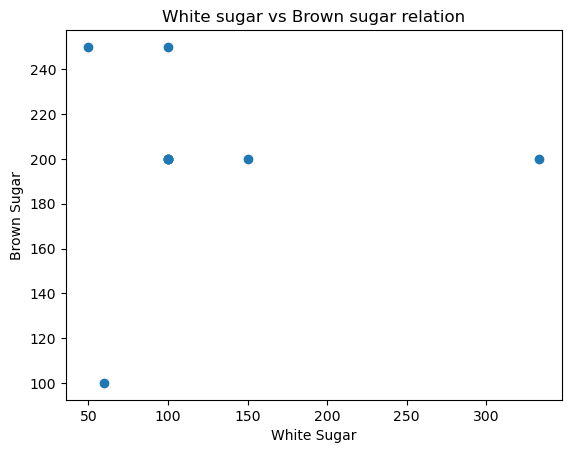

In [99]:
import matplotlib.pyplot as plt

plt.scatter(df_mix["white"], df_mix["brown"])
plt.xlabel("White Sugar")
plt.ylabel("Brown Sugar")
plt.title("White sugar vs Brown sugar relation")
plt.show()

In [100]:
#---Do a quick analysis of vanilla, salt, baking powder and extra toppings and do basic conditions for these; they are not important for the structure. so spend less time on them---

In [101]:
df_vanilla = df[df["ingredient_type"] == "vanilla"]

In [102]:
df_vanilla["grams_converted"].isna().sum()

np.int64(0)

In [103]:
df_vanilla_grouped = df_vanilla.groupby("Recipe_url")["grams_converted"].sum().reset_index()

df_vanilla_ratios = df_vanilla_grouped.merge(df_pivot[["Recipe_url", "flour"]], on="Recipe_url")

In [104]:
df_vanilla_ratios.sample(20)

,Recipe_url,grams_converted,flour
6,https://joythebaker.com/2023/02/my-best-classi...,10.0,190.0
8,https://preppykitchen.com/blondie-recipe/,10.0,210.0
11,https://www.bbcgoodfood.com/recipes/easy-blondies,5.0,200.0
17,https://www.livewellbakeoften.com/blondie-recipe/,10.0,240.0
20,https://www.recipetineats.com/blondies/,5.0,120.0
26,https://www.yellowblissroad.com/classic-blondi...,7.5,120.0
9,https://sugarspunrun.com/blondies-recipe/,10.0,270.0
4,https://handletheheat.com/blondie-recipe/,10.0,191.0
3,https://cloudykitchen.com/blog/brown-butter-bl...,2.5,140.0
1,https://cakesbymk.com/recipe/easy-blondies-rec...,15.0,210.0


In [105]:
df_vanilla_ratios["vanilla_to_flour"] = df_vanilla_ratios["grams_converted"] / df_vanilla_ratios["flour"]

In [106]:
df_vanilla_ratios["vanilla_to_flour"].describe()

count    27.000000
mean      0.054737
std       0.027708
min       0.017857
25%       0.039352
50%       0.047619
75%       0.066964
max       0.125000
Name: vanilla_to_flour, dtype: float64

In [107]:
#---Convert vanilla extract values from g/mL to teaspoons and tablespoons for ease of use---

def format_vanilla(vanilla_ml):

    tsp = vanilla_ml / 5
    tsp_rounded = round(tsp)

    tbsp = tsp_rounded // 3
    remaining_tsp = tsp_rounded % 3

    if tbsp > 0 and remaining_tsp > 0:
        return f"{tbsp} tbsp + {remaining_tsp} tsp"
    elif tbsp > 0:
        return f"{tbsp} tbsp"
    else:
        return f"{remaining_tsp} tsp"

In [108]:
df_baking_powder = df[df["ingredient_type"] == "baking_powder"]

In [109]:
df_baking_powder_grouped = df_baking_powder.groupby("Recipe_url")[["grams_converted"]].sum().reset_index()

df_baking_powder_ratios = df_baking_powder_grouped.merge(df_pivot[["Recipe_url", "flour"]], on="Recipe_url", how="left")


In [110]:
df_baking_powder_ratios["bp_to_flour"] = df_baking_powder_ratios["grams_converted"] / df_baking_powder_ratios["flour"]

In [111]:
df_baking_powder_ratios["bp_to_flour"].describe()

count    22.000000
mean      0.024148
std       0.040199
min       0.005236
25%       0.009524
50%       0.016667
75%       0.020419
max       0.200000
Name: bp_to_flour, dtype: float64

In [112]:
df_baking_powder_ratios.sample(20)

,Recipe_url,grams_converted,flour,bp_to_flour
1,https://cakesbymk.com/recipe/easy-blondies-rec...,2.0,210.0,0.009524
16,https://www.rachelcooks.com/blondie-recipe/,2.0,120.0,0.016667
3,https://cloudykitchen.com/blog/brown-butter-bl...,1.0,140.0,0.007143
11,https://www.bbcgoodfood.com/recipes/easy-blondies,2.0,200.0,0.010000
21,https://www.yellowblissroad.com/classic-blondi...,2.0,120.0,0.016667
10,https://veenaazmanov.com/classic-blondies-recipe/,6.0,240.0,0.025000
5,https://iambaker.net/blondie-recipe/,4.0,285.0,0.014035
18,https://www.tastingtable.com/2122453/best-butt...,2.0,210.0,0.009524
2,https://cheflindseyfarr.com/classic-chewy-blon...,5.0,270.0,0.018519
4,https://handletheheat.com/blondie-recipe/,1.0,191.0,0.005236


In [113]:
df[df["ingredient_type"] == "baking_powder"]["Recipe_url"].nunique()

22

In [114]:
df_baking_powder_ratios.groupby("grams_converted")["flour"].max()

grams_converted
1.0     191.0
2.0     270.0
4.0     300.0
5.0     270.0
6.0     240.0
8.0     360.0
24.0    120.0
Name: flour, dtype: float64

In [115]:
def format_baking_powder(bp_g):
    tsp = bp_g / 4
    tsp_rounded = round(tsp * 4) / 4  # round to nearest 1/4 tsp

    formats = {
        0.25: "1/4 tsp",
        0.5: "1/2 tsp",
        0.75: "3/4 tsp",
        1.0: "1 tsp"
    }

    if tsp_rounded in formats:
        return formats[tsp_rounded]
    else:
        return f"{tsp_rounded:g} tsp"

In [116]:
def blondie_ingredient_calculator(flour=None, butter=None, sugar=None):

    butter_to_flour = df_pivot["butter_to_flour"].median()
    sugar_to_flour = df_pivot["sugar_to_flour"].median()
    vanilla_to_flour = df_vanilla_ratios["vanilla_to_flour"].median()
    baking_powder_to_flour = df_baking_powder_ratios["bp_to_flour"].median()

    inputs_provided = sum(x is not None for x in [flour, butter, sugar])

    if inputs_provided == 0:
        return "Please provide one ingredient."
    if inputs_provided > 1:
        return "Please provide ONLY one ingredient at a time."

    # --- Convert everything to flour ---
    if butter is not None:
        flour = butter / butter_to_flour
    elif sugar is not None:
        flour = sugar / sugar_to_flour

    # --- Recompute consistently ---
    butter = flour * butter_to_flour
    sugar = flour * sugar_to_flour

    # --- Vanilla ---
    vanilla_ml = flour * vanilla_to_flour
    vanilla_text = format_vanilla(vanilla_ml)

    # --- Baking Powder ---
    baking_powder_g = flour * baking_powder_to_flour
    baking_powder_text = format_baking_powder(baking_powder_g)

    # --- Eggs ---
    eggs = estimate_eggs(flour, butter)

    result = {
        "flour_g": round(flour, 1),
        "baking_powder": baking_powder_text,
        "butter_g": round(butter, 1),
        "brown_sugar_g": round(sugar, 1),
        "eggs": eggs,
        "vanilla_extract": vanilla_text,
        "add-ins": "100–200g recommended (baking chocolate, chocolate chips, nuts, etc.)",
        'optional': "add 2 tsp cornstarch for extra tenderness, +1 egg yolk for fudgier texture, or replace some brown sugar with white for a crackly top."
    }

    return result

In [121]:
blondie_ingredient_calculator(butter=150)

{'flour_g': 159.2,
 'baking_powder': '3/4 tsp',
 'butter_g': 150.0,
 'brown_sugar_g': 238.8,
 'eggs': 1,
 'vanilla_extract': '2 tsp',
 'add-ins': '100–200g recommended (baking chocolate, chocolate chips, nuts, etc.)',
 'optional': 'add 2 tsp cornstarch for extra tenderness, +1 egg yolk for fudgier texture, or replace some brown sugar with white for a crackly top.'}

In [118]:
pip install gradio

Note: you may need to restart the kernel to use updated packages.


In [119]:
import gradio as gr
def gradio_interface(flour=None, butter=None, sugar=None):
    result = blondie_ingredient_calculator(flour, butter, sugar)
    if isinstance(result, str):
        return result
    else:
        return "\n".join(f"{k}: {v}" for k, v in result.items())

In [120]:
demo = gr.Interface(fn=gradio_interface, inputs=["number", "number", "number"], outputs="text")
demo.launch() 

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
